# ESM2 foundation-model benchmark — figures

Reads the per-run results of the foundation sweep and draws, for both
**Test R²** and **Test Spearman ρ**:

1. learning curves per dataset, one line per checkpoint, one figure per family;
2. a summary figure — mean per checkpoint and dataset family (bars), and mean
   across datasets against training size (lines).

Colour encodes checkpoint size on a single-hue ordinal ramp (bigger model =
darker) with a distinct marker per checkpoint, so the figures survive greyscale
printing and colour-vision deficiency. Error bars are ±1 SD across seeds in the
per-dataset curves and ±1 s.e.m. across datasets in the summary.

## Setup

In [55]:
import os
import string

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# =========================
# Publication styling
# =========================
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

mpl.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5,
    "text.color": INK,
    "axes.labelcolor": INK,
    # Black axes and black tick marks, matching the other notebooks.
    "xtick.color": INK,
    "ytick.color": INK,
    "xtick.labelcolor": INK,
    "ytick.labelcolor": INK,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4.5,
    "ytick.major.size": 4.5,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "axes.edgecolor": INK,
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.6,
    "grid.linestyle": "-",
    "legend.frameon": False,
})

# =========================
# Checkpoints
# =========================
VARIANT_LABELS = {
    "facebook/esm2_t6_8M_UR50D":    "ESM2 8M",
    "facebook/esm2_t12_35M_UR50D":  "ESM2 35M",
    "facebook/esm2_t30_150M_UR50D": "ESM2 150M",
    "facebook/esm2_t33_650M_UR50D": "ESM2 650M",
}
VARIANT_ORDER = ["ESM2 8M", "ESM2 35M", "ESM2 150M", "ESM2 650M"]

# Single-hue ordinal ramp: the checkpoints are ordered by size, so lightness
# carries that order. Validated as an ordinal ramp (monotone lightness, every
# adjacent gap >= 0.06, light end clears the surface at 2.4:1).
COLORS = {
    "ESM2 8M":   "#6da7ec",
    "ESM2 35M":  "#2a78d6",
    "ESM2 150M": "#1c5cab",
    "ESM2 650M": "#0d366b",
}
# Second channel, so identity never rests on colour alone.
MARKERS = {"ESM2 8M": "o", "ESM2 35M": "s", "ESM2 150M": "^", "ESM2 650M": "D"}

FAMILIES = ["substitutions", "indels", "peptides"]
FAMILY_TITLE = {"substitutions": "Substitutions", "indels": "Indels",
                "peptides": "Peptides"}

METRICS = {
    "Test R2": r"Test $R^2$",
    "Test Spearman Correlation": r"Test Spearman $\rho$",
}

DATASET_SHORT = {
    "EC_all_40": "E. coli AMPs", "SA_all_40": "S. aureus AMPs",
    "PA_all_40": "P. aeruginosa AMPs", "hemopi2_all": "HemoPI2",
}

letters = list(string.ascii_lowercase)


def find_results_root(*candidates):
    """Return the first results folder that exists.

    The SLURM jobs write to simulate_experiments/simulation_output/; the other
    spellings are copies (e.g. results moved off the cluster), so the jobs' own
    output is checked first and a stale copy can never shadow fresh results.
    """
    for c in candidates:
        if os.path.isdir(c):
            print(f"Reading results from {os.path.abspath(c)}")
            return c
    raise FileNotFoundError(
        "No benchmark results folder found. Looked in:\n  "
        + "\n  ".join(os.path.abspath(c) for c in candidates)
    )


SIM_ROOT = find_results_root(
    "./simulate_experiments/simulation_output/foundations",
    "./simulation_output/foundations",
    "./simulation_outputs/foundations",
)


def short_name(d):
    """Readable panel title: AMP sets by name, DMS assays by their first two tokens."""
    if d in DATASET_SHORT:
        return DATASET_SHORT[d]
    return " ".join(d.replace("_indels", "").split("_")[:2])


def zero_line(ax):
    """Reference line at 0 - only when 0 lies inside the data range, and it
    never widens the axis, so the data keeps the full panel height."""
    lo, hi = ax.get_ylim()
    if lo < 0 < hi:
        ax.axhline(0, color=AXIS, linewidth=0.8, zorder=1)
        ax.set_ylim(lo, hi)


#: Small horizontal offset per checkpoint so the four sets of error bars do not
#: stack on each other: additive on a categorical axis, multiplicative on log.
DODGE_CAT = dict(zip(VARIANT_ORDER, [-0.12, -0.04, 0.04, 0.12]))
DODGE_LOG = dict(zip(VARIANT_ORDER, [0.955, 0.985, 1.015, 1.045]))


def save(fig, stem):
    fig.savefig(f"{stem}.png")
    fig.savefig(f"{stem}.pdf")
    print(f"Saved {stem}.png / .pdf")

Reading results from /Users/leoan/Documents/GitHub/SCARSE-repro/code/benchmark/simulate_experiments/simulation_output/foundations


In [56]:
# ------------------------------------------------------------------
# Per-run results for every family, in one frame.
# ------------------------------------------------------------------
frames = []
for family in FAMILIES:
    path = os.path.join(SIM_ROOT, family, "simulation_summary_all.csv")
    if not os.path.exists(path):
        print(f"Missing (run foundations_{family}.sh and aggregate it): {path}")
        continue
    d = pd.read_csv(path)
    d["Family"] = family
    frames.append(d)

if not frames:
    raise FileNotFoundError(f"No foundation-benchmark results under {SIM_ROOT}")

runs = pd.concat(frames, ignore_index=True)
runs["Variant"] = runs["Foundation"].map(VARIANT_LABELS)
runs = runs[runs["Variant"].notna()].copy()

#: Training sizes are a per-family design choice, so a "mean across datasets at
#: training size n" is only comparable within one grid. Families that share a
#: grid are averaged together; the others are drawn as their own line.
GRIDS = {}
for family in FAMILIES:
    sizes = tuple(sorted(runs.loc[runs["Family"] == family, "Train Size"].unique()))
    GRIDS.setdefault(sizes, []).append(family)

#: Line style per grid: solid for the grid most families share, dashed otherwise.
_by_size = sorted(GRIDS, key=lambda s: -len(GRIDS[s]))
GRID_STYLE = {s: ("-" if i == 0 else "--") for i, s in enumerate(_by_size)}

print(f"{len(runs)} runs | {runs['Dataset'].nunique()} datasets | "
      f"{runs['Seed'].nunique()} seeds")
for sizes, fams in GRIDS.items():
    print(f"  train-size grid {[int(t) for t in sizes]}: {', '.join(fams)}")

5520 runs | 24 datasets | 10 seeds
  train-size grid [20, 50, 75, 100, 200, 350, 500]: substitutions, peptides
  train-size grid [20, 40, 60, 80]: indels


In [57]:
# ------------------------------------------------------------------
# Aggregations. Every mean carries the spread that goes with it.
# ------------------------------------------------------------------
def curve_stats(family, metric):
    """Mean and SD over seeds, per dataset, checkpoint and training size."""
    d = runs[runs["Family"] == family]
    return (d.groupby(["Dataset", "Variant", "Train Size"], as_index=False)[metric]
             .agg(mean="mean", sd="std", n="count"))


def dataset_means(metric):
    """One value per (family, dataset, checkpoint): the mean over seeds and sizes."""
    return (runs.groupby(["Family", "Dataset", "Variant"], as_index=False)[metric]
                .mean()
                .rename(columns={metric: "value"}))


def group_means(metric):
    """Mean +/- s.e.m. per checkpoint and family, with datasets as the unit.

    Each dataset contributes one number, so a family with many training sizes
    does not count more than a family with few.
    """
    per_ds = dataset_means(metric)
    out = []
    for scope, d in [(FAMILY_TITLE[f], per_ds[per_ds["Family"] == f]) for f in FAMILIES] \
                    + [("All datasets", per_ds)]:
        for variant in VARIANT_ORDER:
            v = d[d["Variant"] == variant]["value"]
            out.append({"Scope": scope, "Variant": variant,
                        "mean": v.mean(),
                        "sem": v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else np.nan,
                        "n datasets": len(v)})
    return pd.DataFrame(out)


def size_means(metric, families):
    """Mean +/- s.e.m. across datasets per checkpoint and training size."""
    d = runs[runs["Family"].isin(families)]
    per_ds = (d.groupby(["Dataset", "Variant", "Train Size"], as_index=False)[metric]
                .mean())
    return (per_ds.groupby(["Variant", "Train Size"])[metric]
                  .agg(mean="mean",
                       sem=lambda s: s.std(ddof=1) / np.sqrt(s.count()),
                       n="count")
                  .reset_index())


SCOPE_ORDER = [FAMILY_TITLE[f] for f in FAMILIES] + ["All datasets"]
print(group_means("Test R2").round(3).to_string(index=False))

        Scope   Variant  mean   sem  n datasets
Substitutions   ESM2 8M 0.424 0.067          10
Substitutions  ESM2 35M 0.452 0.072          10
Substitutions ESM2 150M 0.479 0.082          10
Substitutions ESM2 650M 0.485 0.083          10
       Indels   ESM2 8M 0.551 0.052          10
       Indels  ESM2 35M 0.620 0.052          10
       Indels ESM2 150M 0.665 0.052          10
       Indels ESM2 650M 0.678 0.054          10
     Peptides   ESM2 8M 0.034 0.042           4
     Peptides  ESM2 35M 0.018 0.040           4
     Peptides ESM2 150M 0.023 0.031           4
     Peptides ESM2 650M 0.024 0.043           4
 All datasets   ESM2 8M 0.412 0.051          24
 All datasets  ESM2 35M 0.449 0.057          24
 All datasets ESM2 150M 0.480 0.061          24
 All datasets ESM2 650M 0.488 0.062          24


## Learning curves per dataset

Laid out for a printed page: full double-column width (7.2 in), portrait.
Substitutions and indels get one figure per metric, datasets in two columns.
Peptides has only four datasets, so Test R² (left column) and Test Spearman ρ
(right column) share one figure, one dataset per row. Error bars ±1 SD across
seeds; every panel's y-axis is fitted to its own data.

In [58]:
#: Journal double-column width, in inches.
PAGE_WIDTH = 7.2


def panel_letter(ax, i):
    """Bold panel letter at the top-left, a fixed distance in points outside the
    axes, so it sits the same way on every panel whatever its size."""
    ax.annotate(letters[i], xy=(0, 1), xycoords="axes fraction",
                xytext=(-30, 7), textcoords="offset points",
                fontsize=11, fontweight="bold", ha="left", va="bottom")


def model_handles(markersize=4.5, linewidth=1.6):
    return [plt.Line2D([0], [0], color=COLORS[v], marker=MARKERS[v],
                       markersize=markersize, markeredgecolor="white",
                       markeredgewidth=0.7, linewidth=linewidth, label=v)
            for v in VARIANT_ORDER]


def draw_curves(ax, stats, dataset, sizes):
    """One dataset: the metric against training size, one line per checkpoint."""
    x = np.arange(len(sizes))
    for variant in VARIANT_ORDER:
        d = (stats[(stats["Dataset"] == dataset) & (stats["Variant"] == variant)]
             .set_index("Train Size").reindex(sizes))
        if d["mean"].isna().all():
            continue
        ax.errorbar(x + DODGE_CAT[variant], d["mean"].values, yerr=d["sd"].values,
                    color=COLORS[variant], marker=MARKERS[variant],
                    markersize=4, markeredgecolor="white", markeredgewidth=0.6,
                    linewidth=1.4, capsize=1.8, elinewidth=0.7, capthick=0.7,
                    zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(sizes)
    ax.grid(False, axis="x")
    # A lighter, unlabelled gridline halfway between each labelled one.
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(True, axis="y", which="minor", color=GRID, linewidth=0.4)
    ax.tick_params(axis="y", which="minor", length=0)
    ax.margins(x=0.06, y=0.12)          # fitted to the data, error bars included
    zero_line(ax)


def plot_curves(family, metrics, n_cols=2, panel_height=1.65):
    """Portrait learning-curve figure for one family.

    One metric: the datasets fill an n_cols-wide grid.
    Several metrics: one row per dataset, one column per metric.
    """
    stats = {m: curve_stats(family, m) for m in metrics}
    first = next(iter(stats.values()))
    if first.empty:
        print(f"No data for {family}")
        return None
    datasets = sorted(first["Dataset"].unique())
    sizes = sorted(first["Train Size"].unique())

    if len(metrics) == 1:
        n_rows = int(np.ceil(len(datasets) / n_cols))
        cells = [(i // n_cols, i % n_cols, d, metrics[0]) for i, d in enumerate(datasets)]
    else:
        n_rows, n_cols = len(datasets), len(metrics)
        cells = [(r, c, d, m) for r, d in enumerate(datasets)
                 for c, m in enumerate(metrics)]

    fig, axes = plt.subplots(n_rows, n_cols, squeeze=False, layout="constrained",
                             figsize=(PAGE_WIDTH, panel_height * n_rows + 0.9))

    for i, (r, c, dataset, metric) in enumerate(cells):
        ax = axes[r][c]
        draw_curves(ax, stats[metric], dataset, sizes)
        ax.set_title(short_name(dataset))
        if len(metrics) > 1 or c == 0:
            ax.set_ylabel(METRICS[metric])
        if i + n_cols >= len(cells):          # nothing below this panel
            ax.set_xlabel("Training set size")
        panel_letter(ax, i)

    for j in range(len(cells), n_rows * n_cols):
        axes[j // n_cols][j % n_cols].set_visible(False)

    fig.legend(handles=model_handles(), loc="outside lower center",
               ncol=len(VARIANT_ORDER), columnspacing=1.6, handletextpad=0.5)

    tag = "" if len(metrics) > 1 else "_" + ("r2" if metrics[0] == "Test R2" else "spearman")
    save(fig, f"foundation_curves_{family}{tag}")
    plt.show()
    return fig

Saved foundation_curves_substitutions_r2.png / .pdf


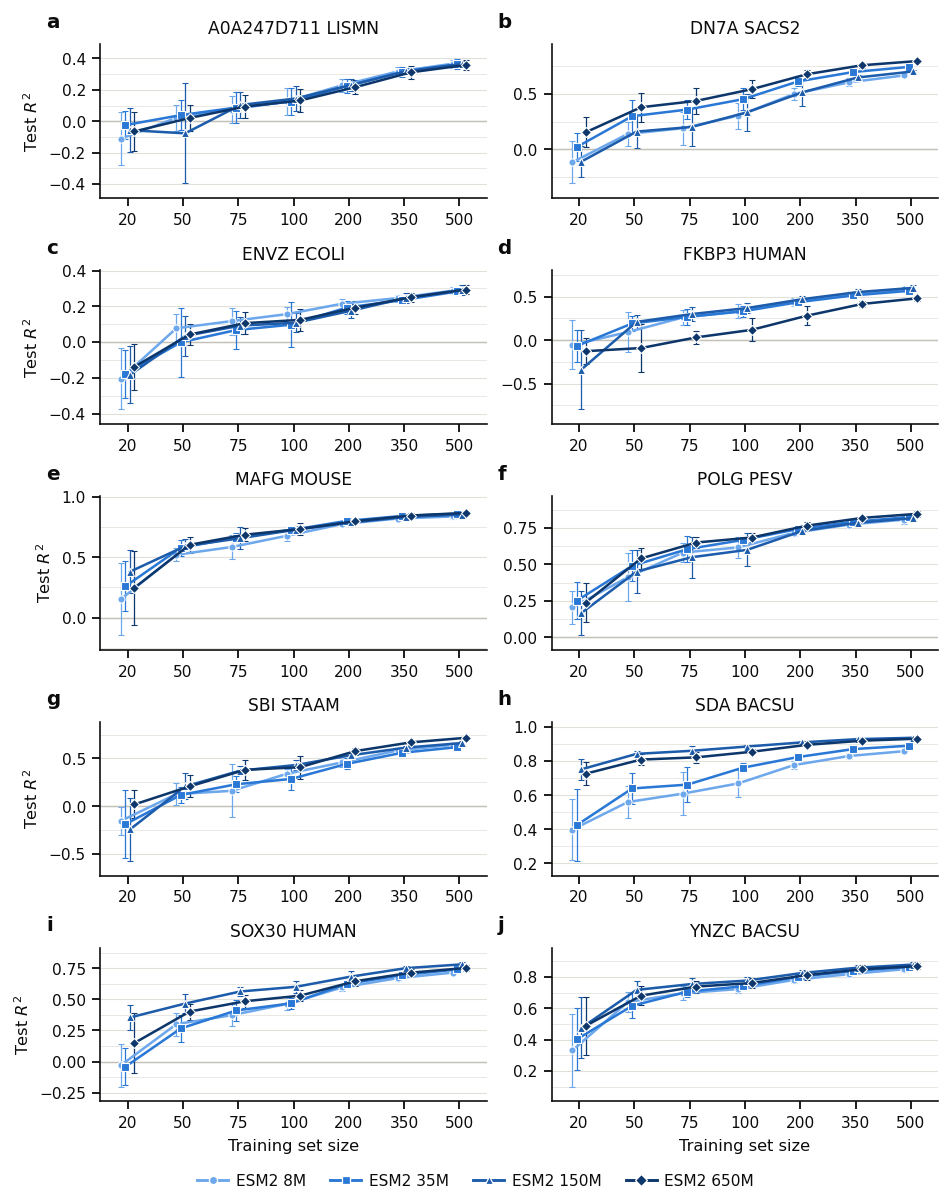

Saved foundation_curves_substitutions_spearman.png / .pdf


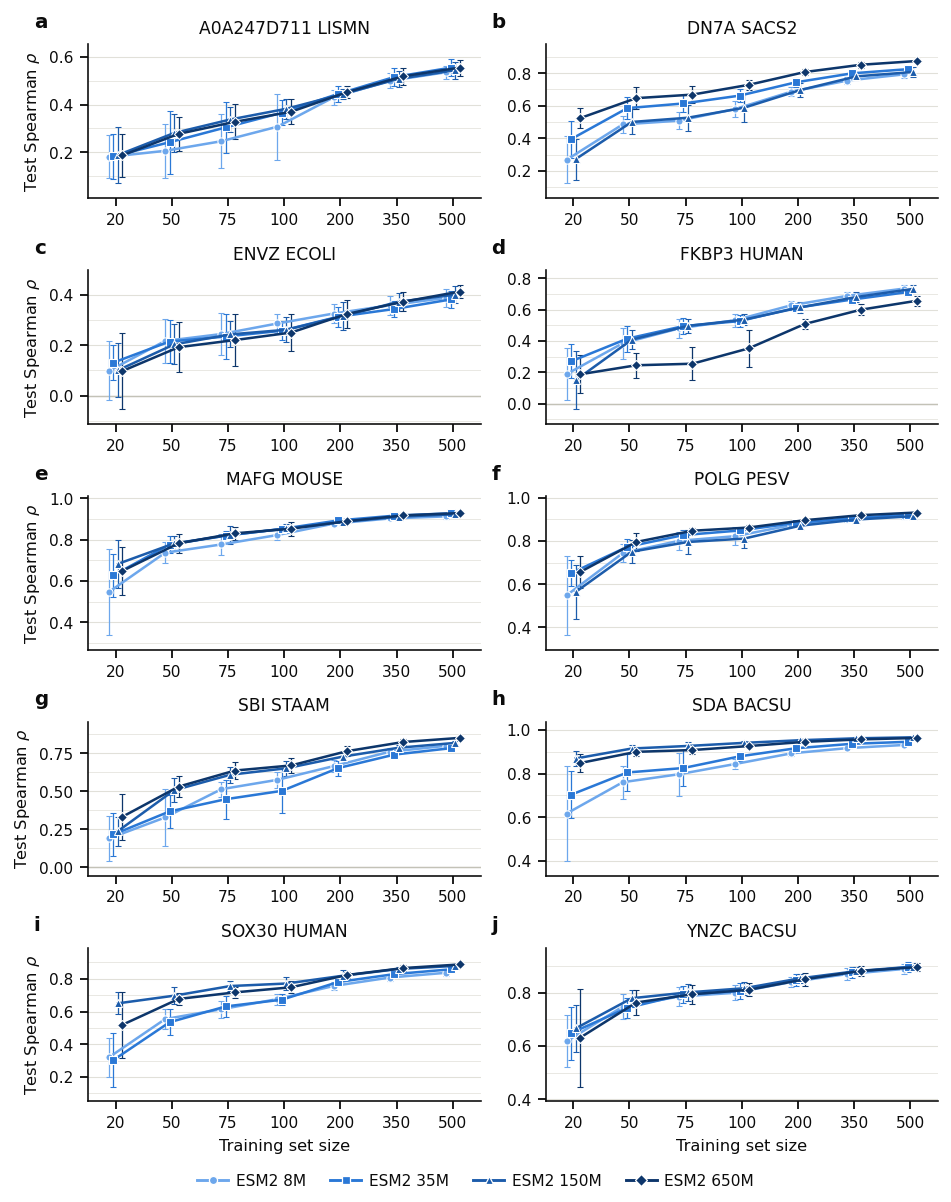

In [59]:
for metric in METRICS:
    _ = plot_curves("substitutions", [metric])

Saved foundation_curves_indels_r2.png / .pdf


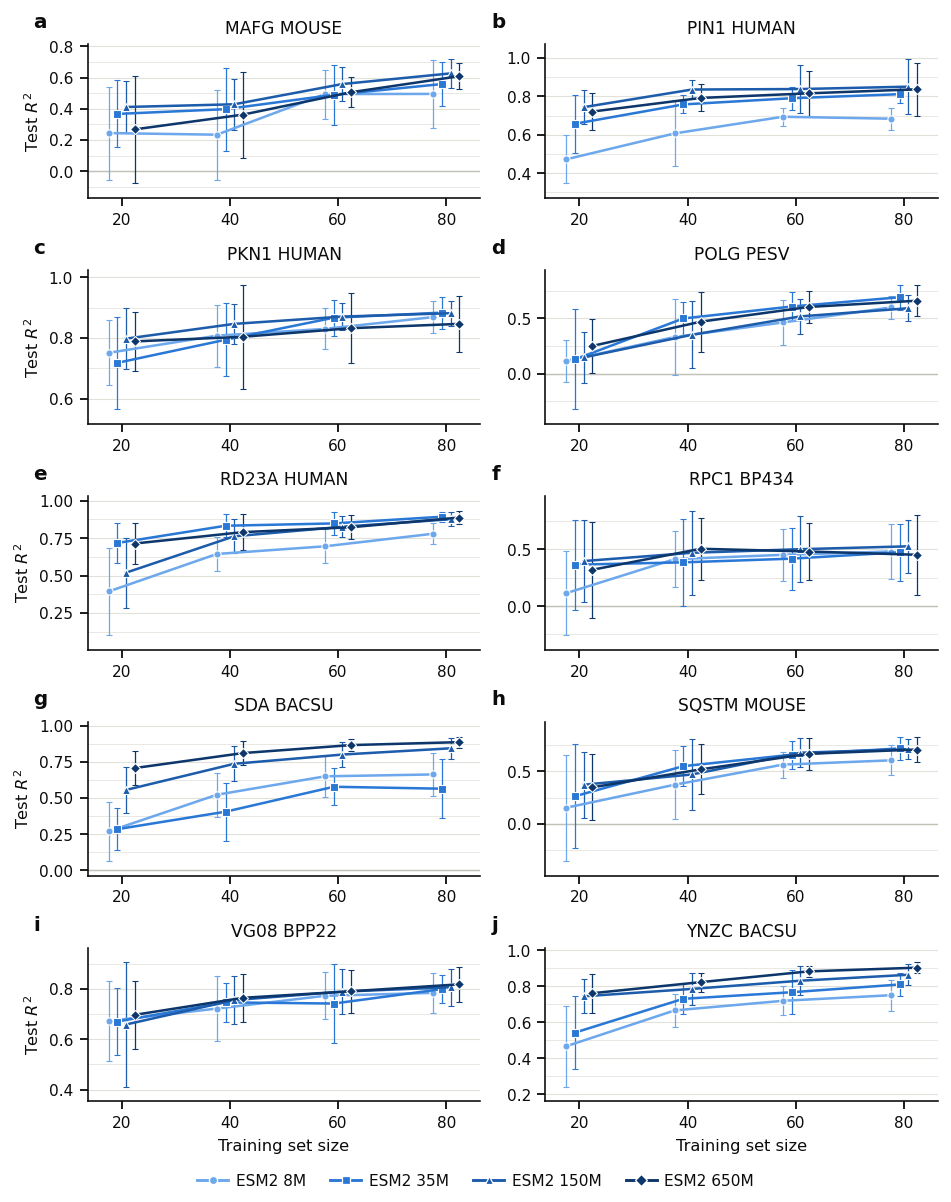

Saved foundation_curves_indels_spearman.png / .pdf


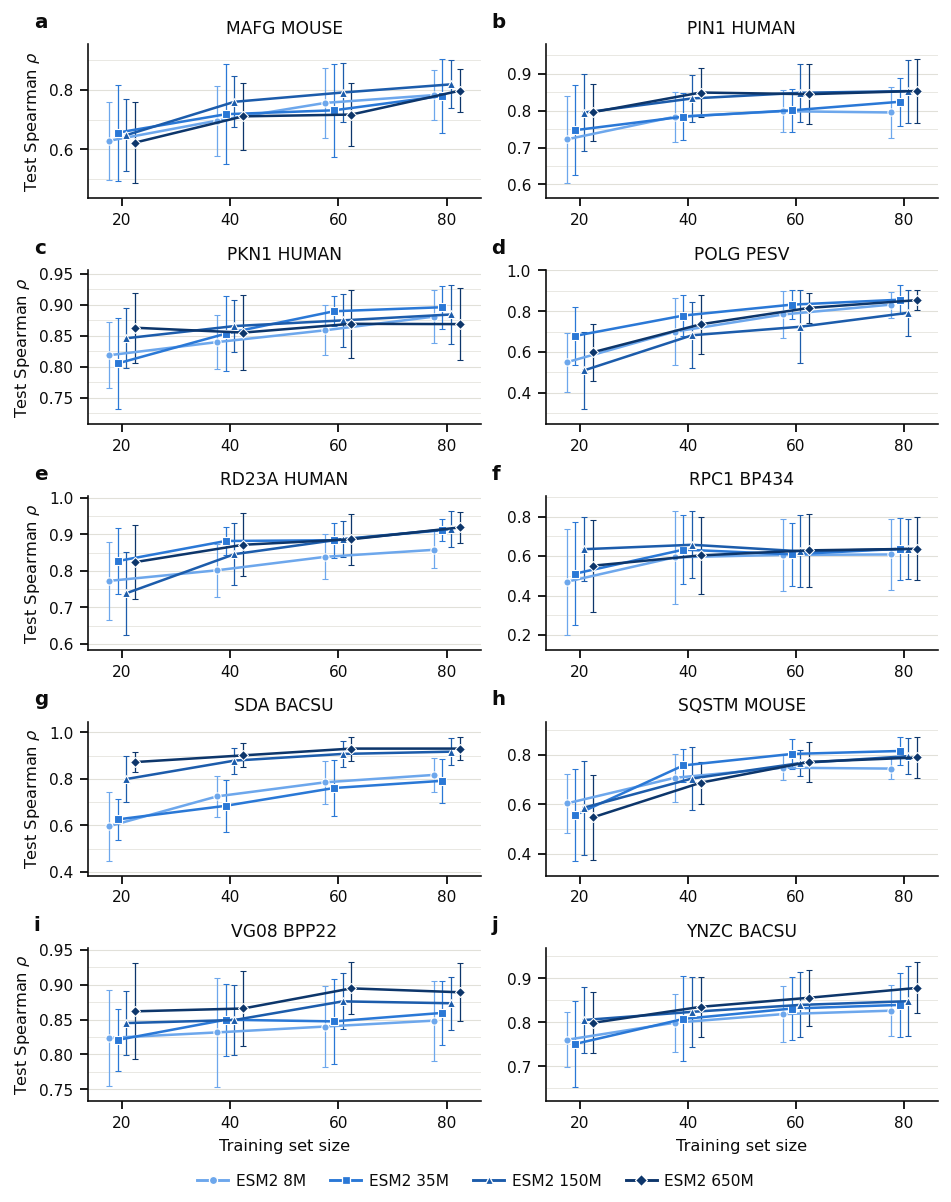

In [60]:
for metric in METRICS:
    _ = plot_curves("indels", [metric])

Saved foundation_curves_peptides.png / .pdf


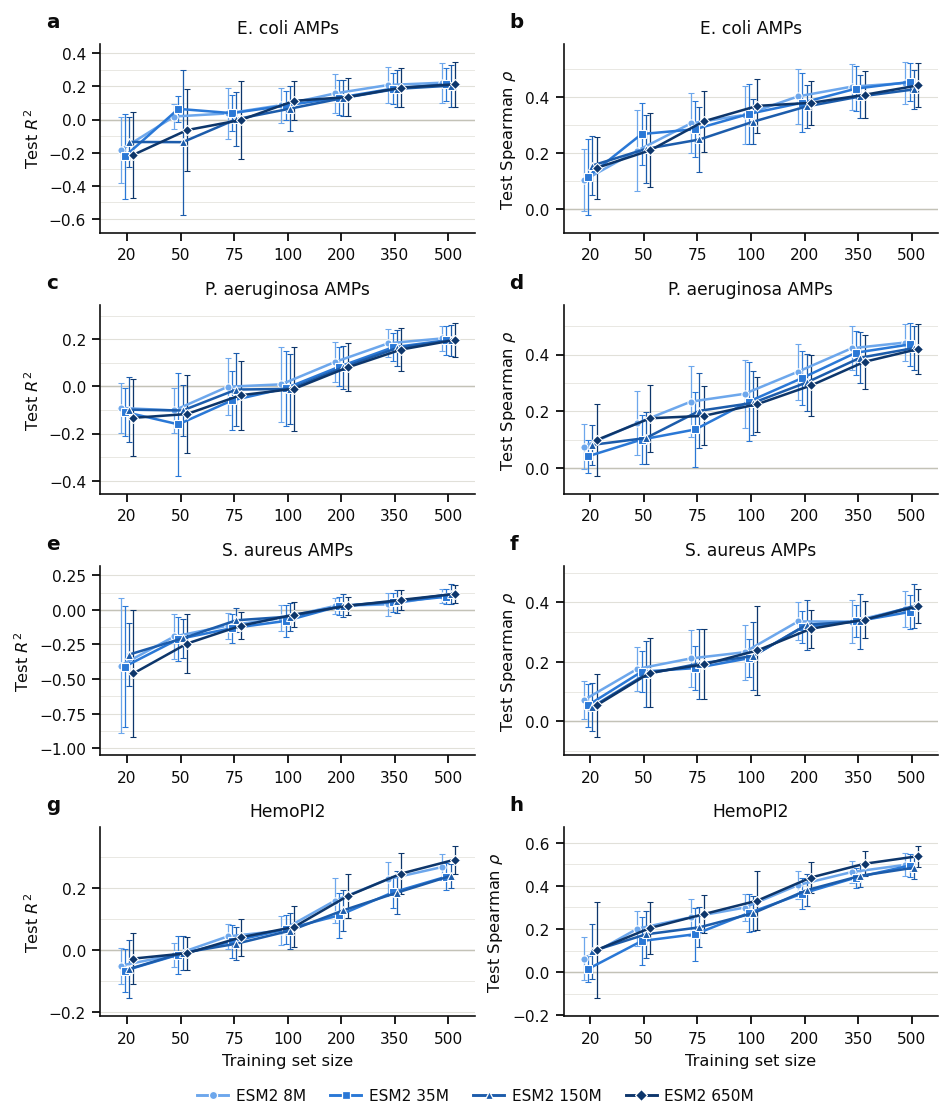

In [61]:
# Four datasets: Test R2 and Test Spearman side by side in one portrait figure.
_ = plot_curves("peptides", list(METRICS), panel_height=1.9)

## Summary across datasets

**a, b** — mean per checkpoint and dataset family, datasets as the unit, error
bars ±1 s.e.m. across datasets.
**c, d** — mean across datasets at each training size, error bars ±1 s.e.m.

The training-size grid is a per-family design choice: substitutions and
peptides run 20–500, indels 20–80. A single line over the union of both grids
would change which datasets it averages from point to point, so each grid is
drawn as its own line — solid for the shared 20–500 grid, dashed for indels.

In [62]:
def plot_summary(figsize=(PAGE_WIDTH, 8.6)):
    """Bars per family (top) and curves against training size (bottom), both metrics."""
    metrics = list(METRICS)
    fig, axes = plt.subplots(2, 2, figsize=figsize, layout="constrained")

    # ---------------- top row: mean per family ----------------
    for col, metric in enumerate(metrics):
        ax = axes[0][col]
        g = group_means(metric)
        scopes = [s for s in SCOPE_ORDER if s in set(g["Scope"])]
        slot = 0.82
        width = slot / len(VARIANT_ORDER)
        for j, variant in enumerate(VARIANT_ORDER):
            d = (g[g["Scope"].isin(scopes) & (g["Variant"] == variant)]
                 .set_index("Scope").reindex(scopes))
            offset = -slot / 2 + width * (j + 0.5)
            ax.bar(np.arange(len(scopes)) + offset, d["mean"].values,
                   width * 0.88,                     # leftover is the surface gap
                   yerr=d["sem"].values, color=COLORS[variant], label=variant,
                   error_kw=dict(elinewidth=0.8, capthick=0.8, ecolor=INK_2),
                   capsize=2, zorder=3)

        ax.set_xticks(np.arange(len(scopes)))
        ax.set_xticklabels(scopes)
        ax.set_ylabel(f"Mean {METRICS[metric]}")
        ax.grid(False, axis="x")
        ax.margins(y=0.14)
        zero_line(ax)

    # ---------------- bottom row: mean against training size ----------------
    for col, metric in enumerate(metrics):
        ax = axes[1][col]
        for sizes, fams in GRIDS.items():
            style = GRID_STYLE[sizes]
            s = size_means(metric, fams)
            for variant in VARIANT_ORDER:
                d = s[s["Variant"] == variant].sort_values("Train Size")
                if d.empty:
                    continue
                ax.errorbar(d["Train Size"] * DODGE_LOG[variant], d["mean"], yerr=d["sem"],
                            color=COLORS[variant], marker=MARKERS[variant],
                            markersize=4.5, markeredgecolor="white", markeredgewidth=0.7,
                            linewidth=1.6, linestyle=style, capsize=2, elinewidth=0.8,
                            capthick=0.8, zorder=3)

        ax.set_xscale("log")
        major = [20, 50, 100, 200, 350, 500]
        shown = [t for t in major if t <= runs["Train Size"].max()]
        ax.set_xticks(shown)
        ax.set_xticklabels([str(t) for t in shown])
        # A log axis auto-adds minor ticks (2,3,4,…× each decade); turn them off
        # so tick marks appear only under the labelled values.
        ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
        ax.tick_params(axis="x", which="minor", length=0)
        ax.set_xlabel("Training set size")
        ax.set_ylabel(f"Mean {METRICS[metric]} across datasets")
        ax.grid(False, axis="x")
        ax.margins(y=0.14)
        zero_line(ax)

    # ---------------- panel letters, legends ----------------
    for i, ax in enumerate(axes.flatten()):
        panel_letter(ax, i)

    fig.legend(handles=model_handles(markersize=5, linewidth=1.8),
               loc="outside upper center", ncol=len(VARIANT_ORDER),
               columnspacing=1.8, handletextpad=0.5)

    grid_keys = [plt.Line2D([0], [0], color=MUTED, linewidth=1.6,
                            linestyle=GRID_STYLE[sizes],
                            label=" + ".join(FAMILY_TITLE[f] for f in fams)
                                  + f"  ({min(sizes)}–{max(sizes)})")
                 for sizes, fams in GRIDS.items()]
    axes[1][0].legend(handles=grid_keys, loc="lower right", fontsize=8)

    save(fig, "foundation_summary")
    plt.show()
    return fig

Saved foundation_summary.png / .pdf


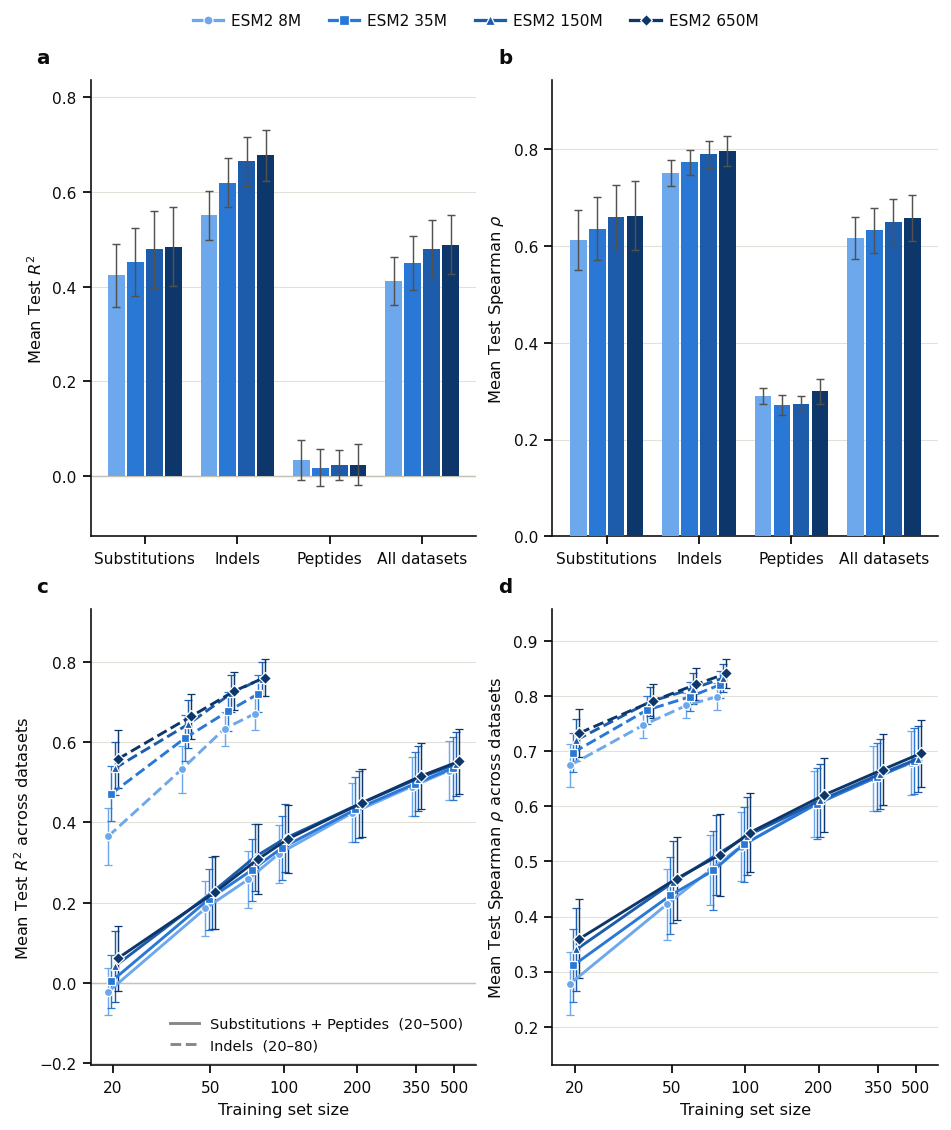

In [63]:
_ = plot_summary()